# Mini-CLIP — From Scratch (NumPy only)

**Read `README.md` first.** Every block cites the section (§) it implements.

No new architecture in this lesson: the towers are lessons 15 and 14, imported from your own past. The new thing is an OBJECTIVE — "matched pairs must coincide" — and this notebook measures, honestly, how much magic that objective buys at 2,700 pairs, including a compositional exam the model will half-pass in the most instructive way possible.

In [1]:
# Block 1 — Imports.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(116)

## Block 2 — The pairs, and the exam declared upfront *(README §1)*

Shapes × sizes with templated captions. Two combos — **large cross** and **small triangle** — are NEVER paired in training: every WORD appears (large squares exist; small crosses exist) but those combinations don't. They are the compositional exam, declared before any training so nothing can be quietly adjusted later.

train: 2700 pairs over 6 combos | test seen: 360 | HELD-OUT exam: 120 ([('large', 'cross'), ('small', 'triangle')])


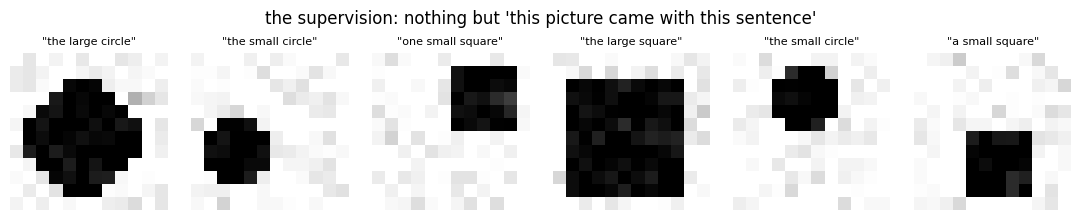

In [2]:
SHAPES = ["square", "circle", "cross", "triangle"]
SIZES = ["small", "large"]
HELD_OUT = [("large", "cross"), ("small", "triangle")]
WORDS = ["<pad>", "a", "the", "one", "small", "large"] + SHAPES
W2I = {w: i for i, w in enumerate(WORDS)}
VT, TL, IM = len(WORDS), 3, 12

def load(path):
    df = pd.read_csv(path)
    imgs = np.array([[float(v) for v in row.split(",")[:-1]] for row in df.pixels]).reshape(-1, IM, IM)
    toks = np.array([[W2I[w] for w in c.split()] + [0]*(TL-len(c.split())) for c in df.caption])
    labels = list(zip(df["size"], df["shape"]))
    return imgs, toks, labels, df

Itr, Ttr, Ltr, _ = load("data/pairs_train.csv")
df_te = pd.read_csv("data/pairs_test.csv")
Ite_all, Tte_all, Lte_all, _ = load("data/pairs_test.csv")
seen_m = (df_te.split == "seen").values
Ite, Tte, Lte = Ite_all[seen_m], Tte_all[seen_m], [l for l, s in zip(Lte_all, seen_m) if s]
Izs, Tzs, Lzs = Ite_all[~seen_m], Tte_all[~seen_m], [l for l, s in zip(Lte_all, seen_m) if not s]
print(f"train: {len(Itr)} pairs over 6 combos | test seen: {len(Ite)} | HELD-OUT exam: {len(Izs)} ({HELD_OUT})")

fig, axes = plt.subplots(1, 6, figsize=(11, 2.2))
for ax, i in zip(axes, range(6)):
    ax.imshow(Itr[i], cmap="gray_r"); ax.axis("off")
    ax.set_title(f'"{ " ".join(WORDS[t] for t in Ttr[i] if t) }"', fontsize=8)
plt.suptitle("the supervision: nothing but 'this picture came with this sentence'")
plt.tight_layout(); plt.show()

## Block 3 — The towers: imports from your own past *(README §3.1, §3.4)*

Image tower = one lesson-15 ViT block (9 patches + CLS). Text tower = one lesson-14 encoder block (3 word tokens, mean-pooled). ONE shared block implementation serves both — because after tokenization, the engine never knew the difference. Total: 19,297 parameters including one scalar you'll meet in Block 5.

In [3]:
D, DH, HEADS, FF, E = 32, 8, 4, 64, 16
PSI, NPI = 4, 9
TI = NPI + 1

def softmax(Z):
    Z = Z - Z.max(axis=-1, keepdims=True)
    e = np.exp(Z)
    return e / e.sum(axis=-1, keepdims=True)

def layernorm(x, g, b, eps=1e-5):
    mu = x.mean(-1, keepdims=True); var = x.var(-1, keepdims=True)
    xh = (x - mu) / np.sqrt(var + eps)
    return g * xh + b, (xh, np.sqrt(var + eps))

def layernorm_back(dout, g, cache):
    xh, std = cache
    dxh = dout * g
    dg = (dout * xh).sum(axis=(0, 1)); db = dout.sum(axis=(0, 1))
    dx = (dxh - dxh.mean(-1, keepdims=True) - xh * (dxh * xh).mean(-1, keepdims=True)) / std
    return dx, dg, db

def patchify(imgs):
    m = imgs.shape[0]
    return imgs.reshape(m, 3, PSI, 3, PSI).transpose(0, 1, 3, 2, 4).reshape(m, NPI, PSI*PSI)

def init_params(seed=0):
    rs = np.random.default_rng(seed)
    def W(*s): return rs.normal(0, 0.15, s)
    P = {"logit_scale": np.array(np.log(1/0.07))}          # CLIP's exact init — Block 5
    P.update({"i_Wp": W(16, D), "i_bp": np.zeros(D), "i_CLS": W(D), "i_Pos": W(TI, D),
              "i_g1": np.ones(D), "i_b1": np.zeros(D),
              "i_Wq": W(D, D), "i_Wk": W(D, D), "i_Wv": W(D, D), "i_Wo": W(D, D),
              "i_g2": np.ones(D), "i_b2": np.zeros(D),
              "i_W1": W(D, FF), "i_c1": np.zeros(FF), "i_W2": W(FF, D), "i_c2": np.zeros(D),
              "i_gF": np.ones(D), "i_bF": np.zeros(D), "i_proj": W(D, E)})
    P.update({"t_E": W(VT, D), "t_Pos": W(TL, D),
              "t_g1": np.ones(D), "t_b1": np.zeros(D),
              "t_Wq": W(D, D), "t_Wk": W(D, D), "t_Wv": W(D, D), "t_Wo": W(D, D),
              "t_g2": np.ones(D), "t_b2": np.zeros(D),
              "t_W1": W(D, FF), "t_c1": np.zeros(FF), "t_W2": W(FF, D), "t_c2": np.zeros(D),
              "t_gF": np.ones(D), "t_bF": np.zeros(D), "t_proj": W(D, E)})
    return P

def block_forward(Xc, P, pre, T_):
    def sh(x): return x.reshape(x.shape[0], T_, HEADS, DH).transpose(0, 2, 1, 3)
    def mh(x): return x.transpose(0, 2, 1, 3).reshape(x.shape[0], T_, D)
    A_in, lc1 = layernorm(Xc, P[pre+"g1"], P[pre+"b1"])
    Q, K, Vv = sh(A_in @ P[pre+"Wq"]), sh(A_in @ P[pre+"Wk"]), sh(A_in @ P[pre+"Wv"])
    A = softmax(Q @ K.transpose(0, 1, 3, 2) / np.sqrt(DH))
    X1 = Xc + mh(A @ Vv) @ P[pre+"Wo"]
    F_in, lc2 = layernorm(X1, P[pre+"g2"], P[pre+"b2"])
    Hf = np.maximum(0, F_in @ P[pre+"W1"] + P[pre+"c1"])
    Xo = X1 + (Hf @ P[pre+"W2"] + P[pre+"c2"])
    return Xo, (A_in, lc1, Q, K, Vv, A, X1, F_in, lc2, Hf)

def block_backward(dX, cache, P, G, pre, T_):
    def sh(x): return x.reshape(x.shape[0], T_, HEADS, DH).transpose(0, 2, 1, 3)
    def mh(x): return x.transpose(0, 2, 1, 3).reshape(x.shape[0], T_, D)
    A_in, lc1, Q, K, Vv, A, X1, F_in, lc2, Hf = cache
    dHf = (dX @ P[pre+"W2"].T) * (Hf > 0)
    G[pre+"W2"] += np.einsum("mtf,mtd->fd", Hf, dX); G[pre+"c2"] += dX.sum((0, 1))
    G[pre+"W1"] += np.einsum("mtd,mtf->df", F_in, dHf); G[pre+"c1"] += dHf.sum((0, 1))
    dX1_ln, dg2, db2 = layernorm_back(dHf @ P[pre+"W1"].T, P[pre+"g2"], lc2)
    G[pre+"g2"] += dg2; G[pre+"b2"] += db2
    dX1 = dX + dX1_ln
    Om = mh(A @ Vv)
    G[pre+"Wo"] += np.einsum("mtd,mte->de", Om, dX1)
    dOhd = sh(dX1 @ P[pre+"Wo"].T)
    dA = dOhd @ Vv.transpose(0, 1, 3, 2)
    dVv = A.transpose(0, 1, 3, 2) @ dOhd
    dS = (A * (dA - (dA * A).sum(-1, keepdims=True))) / np.sqrt(DH)
    dQ = dS @ K; dK = dS.transpose(0, 1, 3, 2) @ Q
    dA_in = mh(dQ) @ P[pre+"Wq"].T + mh(dK) @ P[pre+"Wk"].T + mh(dVv) @ P[pre+"Wv"].T
    G[pre+"Wq"] += np.einsum("mtd,mte->de", A_in, mh(dQ))
    G[pre+"Wk"] += np.einsum("mtd,mte->de", A_in, mh(dK))
    G[pre+"Wv"] += np.einsum("mtd,mte->de", A_in, mh(dVv))
    dX_ln, dg1, db1 = layernorm_back(dA_in, P[pre+"g1"], lc1)
    G[pre+"g1"] += dg1; G[pre+"b1"] += db1
    return dX1 + dX_ln

P0 = init_params()
n_params = sum(np.asarray(v).size for v in P0.values())
print(f"two full towers + projections + one scalar: {n_params:,} parameters (README §3.4's economy)")

two full towers + projections + one scalar: 19,297 parameters (README §3.4's economy)


## Block 4 — Onto the sphere *(README §3.1)*

Each tower ends: project to E=16, L2-normalize. On unit vectors, similarity = dot product = cosine — lesson 01's oldest tool, closing the loop. The normalization's backward is the LayerNorm family's last member: subtract the projection onto x̂, divide by the norm.

In [4]:
def normalize(x):
    n = np.linalg.norm(x, axis=-1, keepdims=True)
    return x / n, n

def normalize_back(dxh, xh, n):
    """README §3.1 — d(x/||x||): remove the component along x̂ (the norm depends on every coord)."""
    return (dxh - (dxh * xh).sum(-1, keepdims=True) * xh) / n

def image_encode(P, imgs):
    m = imgs.shape[0]
    pat = patchify(imgs)
    Xs = np.concatenate([np.broadcast_to(P["i_CLS"], (m, 1, D)), pat @ P["i_Wp"] + P["i_bp"]], 1) + P["i_Pos"][None]
    Xo, bc = block_forward(Xs, P, "i_", TI)
    Xf, lcF = layernorm(Xo, P["i_gF"], P["i_bF"])
    raw = Xf[:, 0] @ P["i_proj"]
    eh, n = normalize(raw)
    return eh, (pat, bc, Xf, lcF, eh, n)

def text_encode(P, toks):
    Xs = P["t_E"][toks] + P["t_Pos"][None]
    Xo, bc = block_forward(Xs, P, "t_", TL)
    Xf, lcF = layernorm(Xo, P["t_gF"], P["t_bF"])
    pooled = Xf.mean(axis=1)
    raw = pooled @ P["t_proj"]
    eh, n = normalize(raw)
    return eh, (toks, bc, Xf, lcF, pooled, eh, n)

Ei, _ = image_encode(P0, Itr[:4]); Et, _ = text_encode(P0, Ttr[:4])
print(f"image embeddings {Ei.shape}, text embeddings {Et.shape} — same space, norms {np.linalg.norm(Ei,axis=1).round(3)}")
print("Two data types that share no format now share one geometry (well — they WILL, after Block 6).")

image embeddings (4, 16), text embeddings (4, 16) — same space, norms [1. 1. 1. 1.]
Two data types that share no format now share one geometry (well — they WILL, after Block 6).


## Block 5 — InfoNCE: one diagonal against the world *(README §3.2–3.3)*

Batch of N pairs → N×N similarity matrix × e^τ (τ learnable, CLIP's `logit_scale`). Softmax rows and columns; cross-entropy toward the diagonal, both directions. Predict the gradient before reading it: (softmax − identity) — the (guess − truth) miracle's FIFTH and final appearance, matrix form.

In [5]:
def image_back(P, G, dEh, cache):
    pat, bc, Xf, lcF, eh, n = cache
    draw_ = normalize_back(dEh, eh, n)
    G["i_proj"] += Xf[:, 0].T @ draw_
    dXf = np.zeros_like(Xf); dXf[:, 0] = draw_ @ P["i_proj"].T
    dX, dg, db = layernorm_back(dXf, P["i_gF"], lcF)
    G["i_gF"] += dg; G["i_bF"] += db
    dX = block_backward(dX, bc, P, G, "i_", TI)
    G["i_Pos"] += dX.sum(0); G["i_CLS"] += dX[:, 0].sum(0)
    G["i_Wp"] += np.einsum("mtp,mtd->pd", pat, dX[:, 1:]); G["i_bp"] += dX[:, 1:].sum((0, 1))

def text_back(P, G, dEh, cache):
    toks, bc, Xf, lcF, pooled, eh, n = cache
    draw_ = normalize_back(dEh, eh, n)
    G["t_proj"] += pooled.T @ draw_
    dXf = np.broadcast_to((draw_ @ P["t_proj"].T)[:, None, :] / TL, Xf.shape).copy()
    dX, dg, db = layernorm_back(dXf, P["t_gF"], lcF)
    G["t_gF"] += dg; G["t_bF"] += db
    dX = block_backward(dX, bc, P, G, "t_", TL)
    G["t_Pos"] += dX.sum(0)
    np.add.at(G["t_E"], toks, dX)

def clip_loss_and_grads(P, imgs, toks):
    m = len(imgs)
    Ei, ci = image_encode(P, imgs)
    Et, ct = text_encode(P, toks)
    s = np.exp(P["logit_scale"])
    logits = s * (Ei @ Et.T)                              # every image scored against every caption
    tgt = np.arange(m)
    Pi = softmax(logits); Pt = softmax(logits.T)
    L = 0.5 * (-np.mean(np.log(Pi[tgt, tgt] + 1e-12)) - np.mean(np.log(Pt[tgt, tgt] + 1e-12)))
    dlogits = 0.5 * ((Pi - np.eye(m)) / m + ((Pt - np.eye(m)) / m).T)   # (guess − truth), matrix form
    G = {k: np.zeros_like(v) for k, v in P.items()}
    G["logit_scale"] = np.sum(dlogits * logits)           # τ learns its own sharpness (README §3.3)
    image_back(P, G, s * (dlogits @ Et), ci)
    text_back(P, G, s * (dlogits.T @ Ei), ct)
    return L, G, logits / s

L0, _, _ = clip_loss_and_grads(P0, Itr[:128], Ttr[:128])
print(f"loss at init (batch 128): {L0:.3f}  — clueless baseline would be ln(128) = {np.log(128):.3f}")
print(f"each batch: 128 positives + {128*127:,} negatives, supplied free by the batch arguing with itself")

loss at init (batch 128): 6.466  — clueless baseline would be ln(128) = 4.852
each batch: 128 positives + 16,256 negatives, supplied free by the batch arguing with itself


## Block 6 — Certify, then train *(README §3.2)*

Gradient checks span both towers AND the temperature scalar. Then train and watch the batch similarity matrix transform: mush → burning diagonal.

grad check i_Wq       : analytic +0.0059302  numerical +0.0059302
grad check t_E        : analytic -0.5981312  numerical -0.5981312
grad check logit_scale: analytic +0.8963380  numerical +0.8963380



loss 4.410 -> 3.223 | temperature scale drifted to 13.3


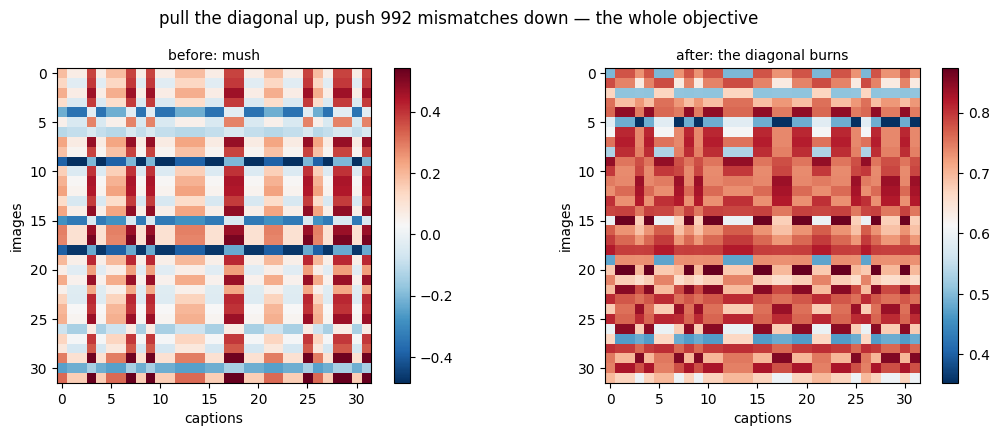

In [6]:
P = init_params(seed=1)
sub_i, sub_t = Itr[:16], Ttr[:16]
_, G, _ = clip_loss_and_grads(P, sub_i, sub_t)
eps = 1e-5
def lossv(): return clip_loss_and_grads(P, sub_i, sub_t)[0]
for key, idx_ in [("i_Wq", (3, 5)), ("t_E", (7, 9)), ("logit_scale", ())]:
    if idx_ == ():
        P[key] = P[key] + eps; Lu = lossv(); P[key] = P[key] - 2*eps; Ld = lossv(); P[key] = P[key] + eps
        a = float(G[key])
    else:
        P[key][idx_] += eps; Lu = lossv(); P[key][idx_] -= 2*eps; Ld = lossv(); P[key][idx_] += eps
        a = G[key][idx_]
    print(f"grad check {key:11s}: analytic {a:+.7f}  numerical {(Lu-Ld)/(2*eps):+.7f}")

class Adam:
    def __init__(self, P, lr):
        self.m = {k: np.zeros_like(v) for k, v in P.items()}
        self.v = {k: np.zeros_like(v) for k, v in P.items()}
        self.lr, self.t = lr, 0
    def step(self, P, G):
        self.t += 1
        for k in P:
            self.m[k] = 0.9*self.m[k] + 0.1*G[k]
            self.v[k] = 0.999*self.v[k] + 0.001*G[k]**2
            mh = self.m[k]/(1-0.9**self.t); vh = self.v[k]/(1-0.999**self.t)
            P[k] -= self.lr * mh/(np.sqrt(vh)+1e-8)

P = init_params(seed=0)
_, _, sim_before = clip_loss_and_grads(P, Ite[:32], Tte[:32])
opt = Adam(P, 2e-3)
rs = np.random.default_rng(0)
hist = []
for ep in range(60):
    order = rs.permutation(len(Itr)); tot = 0.0
    for s_ in range(0, len(Itr), 128):
        b = order[s_:s_+128]
        L, G, _ = clip_loss_and_grads(P, Itr[b], Ttr[b])
        opt.step(P, G); tot += L * len(b)
    hist.append(tot/len(Itr))
_, _, sim_after = clip_loss_and_grads(P, Ite[:32], Tte[:32])
print(f"\nloss {hist[0]:.3f} -> {hist[-1]:.3f} | temperature scale drifted to {np.exp(P['logit_scale']):.1f}")

fig, axes = plt.subplots(1, 2, figsize=(11, 4.4))
for ax, S, ttl in [(axes[0], sim_before, "before: mush"), (axes[1], sim_after, "after: the diagonal burns")]:
    im = ax.imshow(S, cmap="RdBu_r"); ax.set_title(ttl, fontsize=10)
    ax.set_xlabel("captions"); ax.set_ylabel("images")
    plt.colorbar(im, ax=ax, fraction=0.045)
plt.suptitle("pull the diagonal up, push 992 mismatches down — the whole objective")
plt.tight_layout(); plt.show()

## Block 7 — The loss floor, computed, then metrics the data can support *(README §5)*

Lesson 14's discipline transfers: this loss CANNOT reach 0 — same-combo pairs are interchangeable (any small-square image matches ANY 'a small square' caption), so with ~21 same-combo pairs per 128-batch the floor is ≈ ln(21). Likewise pair-level retrieval is unanswerable BY DESIGN; grade the retrieved CLASS.

In [7]:
per_combo_in_batch = 128 / 6
print(f"loss floor ≈ ln(same-combo pairs per batch) = ln({per_combo_in_batch:.0f}) = {np.log(per_combo_in_batch):.3f}")
print(f"our final loss: {hist[-1]:.3f} — parked just above ITS floor, not 'stuck' (README §5)\n")

Ei_te, _ = image_encode(P, Ite)
Et_te, _ = text_encode(P, Tte)
sim = Ei_te @ Et_te.T
lab_arr = np.array([f"{l[0]} {l[1]}" for l in Lte])
r_i2t = (lab_arr[sim.argmax(1)] == lab_arr).mean()
r_t2i = (lab_arr[sim.argmax(0)] == lab_arr).mean()
print(f"class-level retrieval on fresh pairs — image->caption: {r_i2t:.0%} | caption->image: {r_t2i:.0%} (chance ~17%)")
print("(pair-level top-1 would score ~1% and mean NOTHING: captions describe combos, not instances —")
print(" choose metrics the labels can support; README §9, mistake 1)")

loss floor ≈ ln(same-combo pairs per batch) = ln(21) = 3.060
our final loss: 3.223 — parked just above ITS floor, not 'stuck' (README §5)

class-level retrieval on fresh pairs — image->caption: 82% | caption->image: 67% (chance ~17%)
(pair-level top-1 would score ~1% and mean NOTHING: captions describe combos, not instances —
 choose metrics the labels can support; README §9, mistake 1)


## Block 8 — Zero-shot: classifiers written, not trained *(README §2.4)*

Embed eight SENTENCES; classify fresh images by nearest caption. No head was ever trained. Edit the sentences, and you've edited the classifier.

In [8]:
all_combos = [(sz, sh) for sz in SIZES for sh in SHAPES]
def tokenize(c):
    t = [W2I[w] for w in c.split()]
    return t + [0]*(TL-len(t))

def zero_shot(P, imgs, labels):
    Tt = np.array([tokenize(f"a {sz} {sh}") for sz, sh in all_combos])
    Et, _ = text_encode(P, Tt)
    Ei, _ = image_encode(P, imgs)
    pred = (Ei @ Et.T).argmax(1)
    truth = np.array([all_combos.index(l) for l in labels])
    return pred, truth

pred_s, truth_s = zero_shot(P, Ite, Lte)
acc_seen = (pred_s == truth_s).mean()
print(f"zero-shot 8-way on SEEN combos (fresh images): {acc_seen:.0%}   (chance 12.5%)")
print("The 'classifier' is the sentence list. New class tomorrow? Write a new sentence.")

zero-shot 8-way on SEEN combos (fresh images): 82%   (chance 12.5%)
The 'classifier' is the sentence list. New class tomorrow? Write a new sentence.


## Block 9 — The compositional exam, and the crown-jewel confusion table *(README §2.4)*

Now the held-out combos: every word seen, the combinations never. Aggregate first — then SLICE, because the aggregate is about to hide the most interesting result in the course.

In [9]:
pred_z, truth_z = zero_shot(P, Izs, Lzs)
acc_zs = (pred_z == truth_z).mean()
print(f"zero-shot on HELD-OUT combos: {acc_zs:.0%}   (chance 12.5% — note: possibly BELOW chance)\n")

print("The confusion table — where do the predictions actually land?")
for sz, sh in HELD_OUT:
    m_ = [i for i, l in enumerate(Lzs) if l == (sz, sh)]
    votes = np.bincount(pred_z[m_], minlength=8)
    top2 = votes.argsort()[::-1][:2]
    print(f"  '{sz} {sh}' ->", ", ".join(f"'{all_combos[t][0]} {all_combos[t][1]}' x{votes[t]}" for t in top2))

size_ok = np.mean([all_combos[p][0] == l[0] for p, l in zip(pred_z, Lzs)])
shape_ok = np.mean([all_combos[p][1] == l[1] for p, l in zip(pred_z, Lzs)])
print(f"\nNow SLICE by attribute:  size accuracy {size_ok:.0%}   |   shape accuracy {shape_ok:.0%}")
print()
print("Composition HALF-emerged. 'Large' became a transferable direction — it generalized")
print("to shapes it was never paired with. 'Cross-ness independent of size' did not:")
print("novel-shape-at-novel-size images get absorbed into the nearest SEEN shape cluster, and")
print("because size transfers, the model confidently picks right-size-WRONG-shape captions —")
print("which is why the aggregate can land BELOW chance (systematic, not random, error).")
print()
print("Two lessons for life: (1) an aggregate near 0% hid a near-perfect sub-skill — slice before")
print("you headline; (2) compositionality is purchased with coverage and scale — CLIP's 400M")
print("pairs bought what our 2,700 could only half-afford (README §2.4, §6).")

zero-shot on HELD-OUT combos: 0%   (chance 12.5% — note: possibly BELOW chance)

The confusion table — where do the predictions actually land?
  'large cross' -> 'large triangle' x37, 'large circle' x23
  'small triangle' -> 'small cross' x34, 'small circle' x26

Now SLICE by attribute:  size accuracy 100%   |   shape accuracy 0%

Composition HALF-emerged. 'Large' became a transferable direction — it generalized
to shapes it was never paired with. 'Cross-ness independent of size' did not:
novel-shape-at-novel-size images get absorbed into the nearest SEEN shape cluster, and
because size transfers, the model confidently picks right-size-WRONG-shape captions —
which is why the aggregate can land BELOW chance (systematic, not random, error).

Two lessons for life: (1) an aggregate near 0% hid a near-perfect sub-skill — slice before
you headline; (2) compositionality is purchased with coverage and scale — CLIP's 400M
pairs bought what our 2,700 could only half-afford (README §2.4, §6).


## Block 10 — The space is the artifact *(README §2.5 + the door)*

PCA (lesson 09, full circle) shows both modalities in one geometry; a text query retrieves images with no index. Then the door to the finale.

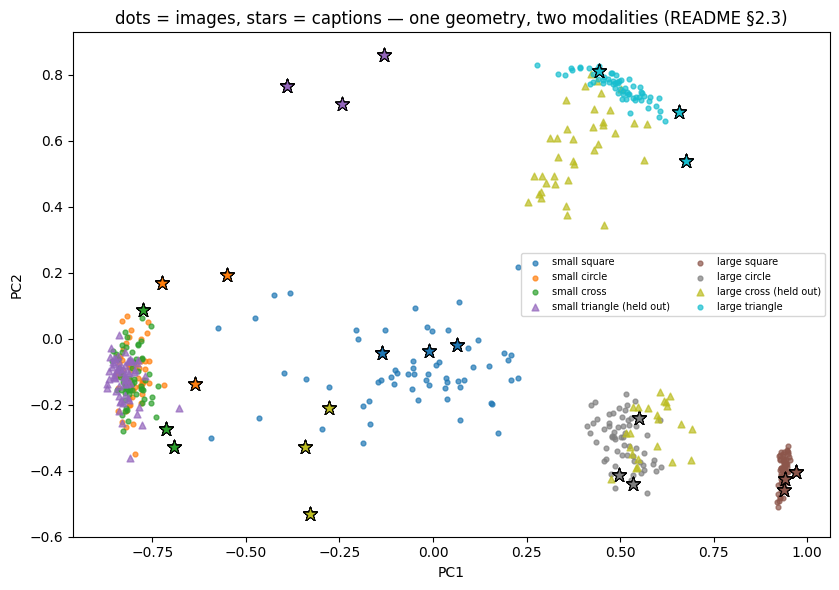

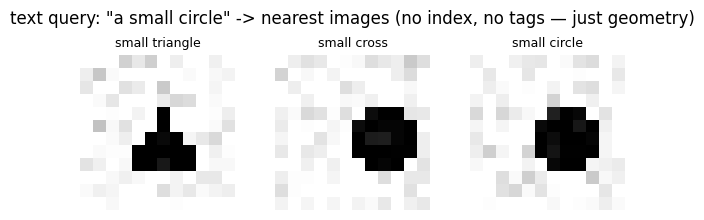

THE DOOR: the shared space is an INTERFACE. Diffusion models generate images whose
embeddings match a sentence; multimodal LLMs project an image tower INTO a language
model's token space so lesson 14's engine can attend to sight. Lesson 17 — the finale —
assembles the concepts that turn all of this machinery into the systems you talk to.


In [10]:
Ei_all, _ = image_encode(P, np.concatenate([Ite, Izs]))
Et_all, _ = text_encode(P, np.concatenate([Tte, Tzs]))
lab_all = Lte + Lzs
Z = np.concatenate([Ei_all, Et_all]); Zc = Z - Z.mean(0)
vals, vecs = np.linalg.eigh(np.cov(Zc.T))
Z2 = Zc @ vecs[:, np.argsort(vals)[::-1][:2]]
ni = len(Ei_all)
cols = plt.cm.tab10(np.linspace(0, 1, 8))
fig, ax = plt.subplots(figsize=(8.5, 6))
for k, cb in enumerate(all_combos):
    mi = [i for i, l in enumerate(lab_all) if l == cb]
    held = cb in HELD_OUT
    ax.scatter(Z2[mi, 0], Z2[mi, 1], s=24 if held else 12, color=cols[k],
               marker="^" if held else "o", alpha=0.7, label=f"{cb[0]} {cb[1]}" + (" (held out)" if held else ""))
    mt = [ni + i for i, l in enumerate(lab_all) if l == cb]
    ax.scatter(Z2[mt, 0], Z2[mt, 1], s=110, color=cols[k], marker="*", edgecolor="black", lw=0.6)
ax.legend(fontsize=7, ncol=2)
ax.set_xlabel("PC1"); ax.set_ylabel("PC2")
ax.set_title("dots = images, stars = captions — one geometry, two modalities (README §2.3)")
plt.tight_layout(); plt.show()

q = "a small circle"
Eq, _ = text_encode(P, np.array([tokenize(q)]))
pool = np.concatenate([Ite, Izs]); pool_lab = Lte + Lzs
Ep, _ = image_encode(P, pool)
top = (Ep @ Eq[0]).argsort()[::-1][:3]
fig, axes = plt.subplots(1, 3, figsize=(6, 2.2))
for ax, ti in zip(axes, top):
    ax.imshow(pool[ti], cmap="gray_r"); ax.set_title(f"{pool_lab[ti][0]} {pool_lab[ti][1]}", fontsize=9); ax.axis("off")
plt.suptitle(f'text query: "{q}" -> nearest images (no index, no tags — just geometry)')
plt.tight_layout(); plt.show()

print("THE DOOR: the shared space is an INTERFACE. Diffusion models generate images whose")
print("embeddings match a sentence; multimodal LLMs project an image tower INTO a language")
print("model's token space so lesson 14's engine can attend to sight. Lesson 17 — the finale —")
print("assembles the concepts that turn all of this machinery into the systems you talk to.")

---
## What you now own

- The two-tower recipe: no new architecture, one new objective — and 19k parameters of pure reuse
- InfoNCE: the diagonal against the world, batch-supplied negatives, learnable temperature, and the miracle's fifth (final) appearance
- Zero-shot classification: classifiers written in prose (8-way, no head)
- The crown jewel: an aggregate failure that sliced into one perfect attribute and one absent one — composition half-emerging, mechanism visible
- Loss floors and metric choice for contrastive data — evaluation discipline, final form

**Next:** `clip_with_library.ipynb` — then the finale, folder `17-modern-llm-concepts`.